# Chest X-ray Classification using DenseNet121

This project uses a pretrained DenseNet121 model to perform multi-label classification on chest X-ray images from the CheXpert dataset.

The goal is to detect multiple medical conditions simultaneously using deep learning.

In [2]:
import os
import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset

from PIL import Image

import torchvision
from torchvision import transforms, models

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    roc_curve,
    auc,
    f1_score,
    confusion_matrix
)

from sklearn.model_selection import train_test_split

from tqdm import tqdm

## Data Loading

We load the CheXpert dataset and prepare it for training, validation, and testing.

In [3]:
csv_path = "data/chexpert/CheXpert-v1.0 batch 1 (validate & csv)/valid.csv"
img_dir = "data/chexpert/CheXpert-v1.0 batch 1 (validate & csv)"

df = pd.read_csv(csv_path)


train_df, temp_df = train_test_split(df, test_size=0.2, random_state=42)
val_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=42)

print(len(train_df), len(val_df), len(test_df))

187 23 24


## Label Distribution

To better understand the dataset, we visualize the distribution of each disease label.

Since the CheXpert dataset contains missing values (NaN) and uncertain labels (-1), 
we preprocess the data by converting all values to numeric format and replacing invalid values with 0.

This ensures correct aggregation and avoids errors during plotting.

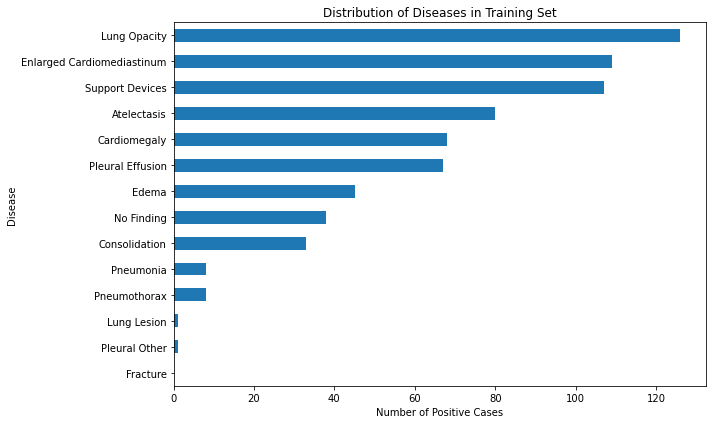

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

labels_df = df.iloc[:, 1:].copy()

labels_df = labels_df.apply(pd.to_numeric, errors='coerce')

labels_df = labels_df.fillna(0)
labels_df = labels_df.replace(-1, 0)

label_counts = labels_df.sum(axis=0).sort_values(ascending=False)

label_cols = [
    'Atelectasis', 'Cardiomegaly', 'Consolidation', 'Edema',
    'Enlarged Cardiomediastinum', 'Fracture', 'Lung Lesion',
    'Lung Opacity', 'No Finding', 'Pleural Effusion',
    'Pleural Other', 'Pneumonia', 'Pneumothorax', 'Support Devices'
]

label_counts = labels_df[label_cols].sum().sort_values(ascending=False)

plt.figure(figsize=(10,6))
label_counts.plot(kind='barh')

plt.title("Distribution of Diseases in Training Set")
plt.xlabel("Number of Positive Cases")
plt.ylabel("Disease")
plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

The dataset is highly imbalanced, which explains why the model performs 
better on frequent classes than rare ones.

## Dataset

We use the CheXpert dataset. The dataset was split into:
- 80% training
- 10% validation
- 10% test

In [5]:
train_df, temp_df = train_test_split(df, test_size=0.2, random_state=42)
val_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=42)

## Dataset Class

We define a custom PyTorch dataset to load images and labels.

In [6]:
class CheXpertDataset(Dataset):
    def __init__(self, df, img_dir, transform=None):
        self.df = df
        self.img_dir = img_dir
        self.transform = transform

        self.label_columns = [
            'Atelectasis','Cardiomegaly','Consolidation','Edema',
            'Enlarged Cardiomediastinum','Fracture','Lung Lesion',
            'Lung Opacity','No Finding','Pleural Effusion',
            'Pleural Other','Pneumonia','Pneumothorax','Support Devices'
        ]

        self.df[self.label_columns] = self.df[self.label_columns].fillna(0)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        path = row["Path"]

        path = path.replace("CheXpert-v1.0/", "")
        img_path = os.path.join(self.img_dir, path) 
       
        if "train" in path:
            path = path.replace("train", "valid")

        img_path = os.path.join(
            self.img_dir,
            path.replace("CheXpert-v1.0/", "CheXpert-v1.0 batch 1 (validate & csv)/")
        )

        img = Image.open(img_path).convert("RGB")

        labels = row[self.label_columns].values.astype(np.float32)
        labels = torch.tensor(labels)

        if self.transform:
            img = self.transform(img)

        return img, labels

## Image Preprocessing

We resize and normalize images to match the pretrained model requirements.

In [7]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [8]:
train_dataset = CheXpertDataset(train_df, img_dir, transform)
val_dataset = CheXpertDataset(val_df, img_dir, transform)
test_dataset = CheXpertDataset(test_df, img_dir, transform)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=16)
test_loader = DataLoader(test_dataset, batch_size=16)

<ipython-input-6-eb2dbf828670>:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self.df[self.label_columns] = self.df[self.label_columns].fillna(0)
<ipython-input-6-eb2dbf828670>:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self.df[self.label_columns] = self.df[self.label_columns].fillna(0)
<ipython-input-6-eb2dbf828670>:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documen

## Model

We use a pretrained DenseNet121 model and modify the final layer.

In [9]:
model = models.densenet121(pretrained=True)
model.classifier = nn.Linear(model.classifier.in_features, 14)

/Users/amnazafar/opt/anaconda3/lib/python3.8/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/Users/amnazafar/opt/anaconda3/lib/python3.8/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=DenseNet121_Weights.IMAGENET1K_V1`. You can also use `weights=DenseNet121_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


## Training

We train the model using BCEWithLogitsLoss for multi-label classification.

In [10]:
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

train_losses = []
val_losses = []

epochs = 10

for epoch in range(epochs):
    model.train()
    total_loss = 0

    for images, labels in train_loader:
        labels = labels.float()

        outputs = model(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    train_losses.append(total_loss / len(train_loader))

   
    model.eval()
    val_loss = 0

    with torch.no_grad():
        for images, labels in val_loader:
            labels = labels.float()
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item()

    val_losses.append(val_loss / len(val_loader))

    print(f"Epoch {epoch+1}, Train Loss: {total_loss:.4f}, Val Loss: {val_loss:.4f}")

Epoch 1, Train Loss: 7.3831, Val Loss: 1.1293
Epoch 2, Train Loss: 5.1474, Val Loss: 0.9849
Epoch 3, Train Loss: 3.9029, Val Loss: 0.8693
Epoch 4, Train Loss: 3.0899, Val Loss: 0.8282
Epoch 5, Train Loss: 2.3624, Val Loss: 0.8031
Epoch 6, Train Loss: 2.0123, Val Loss: 0.8061
Epoch 7, Train Loss: 1.6293, Val Loss: 0.8068
Epoch 8, Train Loss: 1.4230, Val Loss: 0.8107
Epoch 9, Train Loss: 1.2923, Val Loss: 0.8025
Epoch 10, Train Loss: 1.0252, Val Loss: 0.7919


## Training Results

We visualize training and validation loss.

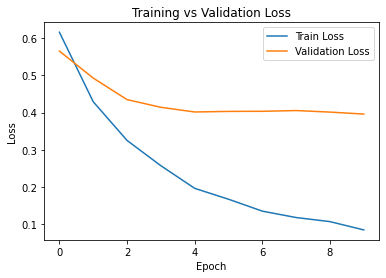

In [11]:
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()

plt.show()

In [12]:
model.eval()

all_labels = []
all_outputs = []

with torch.no_grad():
    for images, labels in val_loader:
        outputs = torch.sigmoid(model(images))

        all_outputs.append(outputs.cpu())
        all_labels.append(labels.cpu())

all_outputs = torch.cat(all_outputs).numpy()
all_labels = torch.cat(all_labels).numpy()

## ROC Curves

We evaluate model performance using ROC curves and AUC.

/Users/amnazafar/opt/anaconda3/lib/python3.8/site-packages/sklearn/metrics/_ranking.py:811: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn("No positive samples in y_true, "
/Users/amnazafar/opt/anaconda3/lib/python3.8/site-packages/sklearn/metrics/_ranking.py:811: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn("No positive samples in y_true, "
/Users/amnazafar/opt/anaconda3/lib/python3.8/site-packages/sklearn/metrics/_ranking.py:811: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn("No positive samples in y_true, "
/Users/amnazafar/opt/anaconda3/lib/python3.8/site-packages/sklearn/metrics/_ranking.py:811: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn("No positive samples in y_true, "


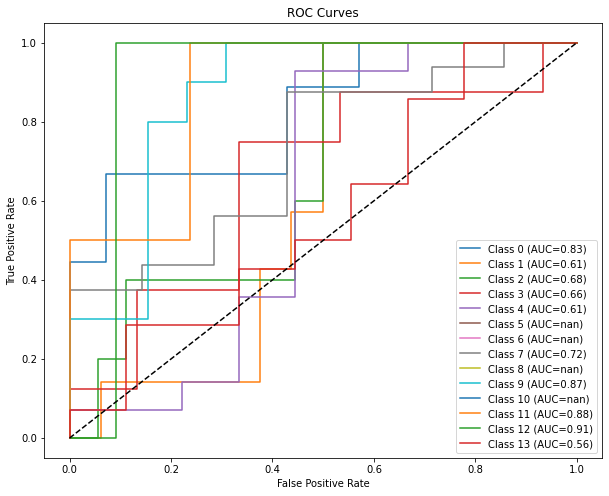

In [13]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))

for i in range(all_labels.shape[1]):
    fpr, tpr, _ = roc_curve(all_labels[:, i], all_outputs[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"Class {i} (AUC={roc_auc:.2f})")

plt.plot([0,1], [0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves")
plt.legend()
plt.show()

We optimize classification thresholds per class instead of using a fixed 0.5,
to better handle class imbalance.

In [21]:
best_thresholds = []

for i in range(all_labels.shape[1]):

    if np.sum(all_labels[:, i]) == 0:
        best_thresholds.append(0.5)
        continue

    fpr, tpr, thresholds = roc_curve(all_labels[:, i], all_outputs[:, i])
    youden = tpr - fpr
    best_thresh = thresholds[np.argmax(youden)]

    best_thresholds.append(best_thresh)


/Users/amnazafar/opt/anaconda3/lib/python3.8/site-packages/sklearn/metrics/_classification.py:1464: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 due to no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(


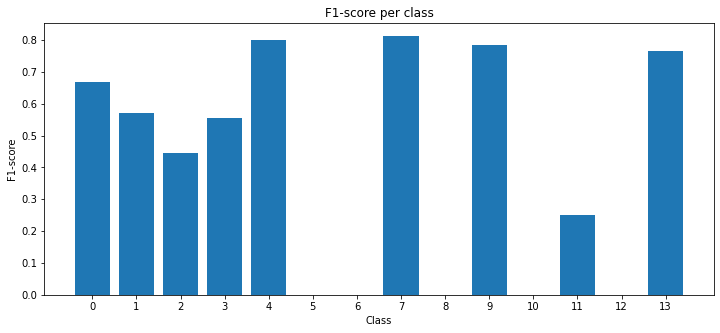

In [22]:
from sklearn.metrics import f1_score

f1_scores = []

for i in range(all_labels.shape[1]):
    preds = (all_outputs[:, i] > best_thresholds[i]).astype(int)
    f1 = f1_score(all_labels[:, i], preds)
    f1_scores.append(f1)

plt.figure(figsize=(12,5))
plt.bar(range(len(f1_scores)), f1_scores)
plt.xticks(range(len(f1_scores)))
plt.title("F1-score per class")
plt.xlabel("Class")
plt.ylabel("F1-score")
plt.show()

## Confusion Matrices

We visualize confusion matrices for all classes.

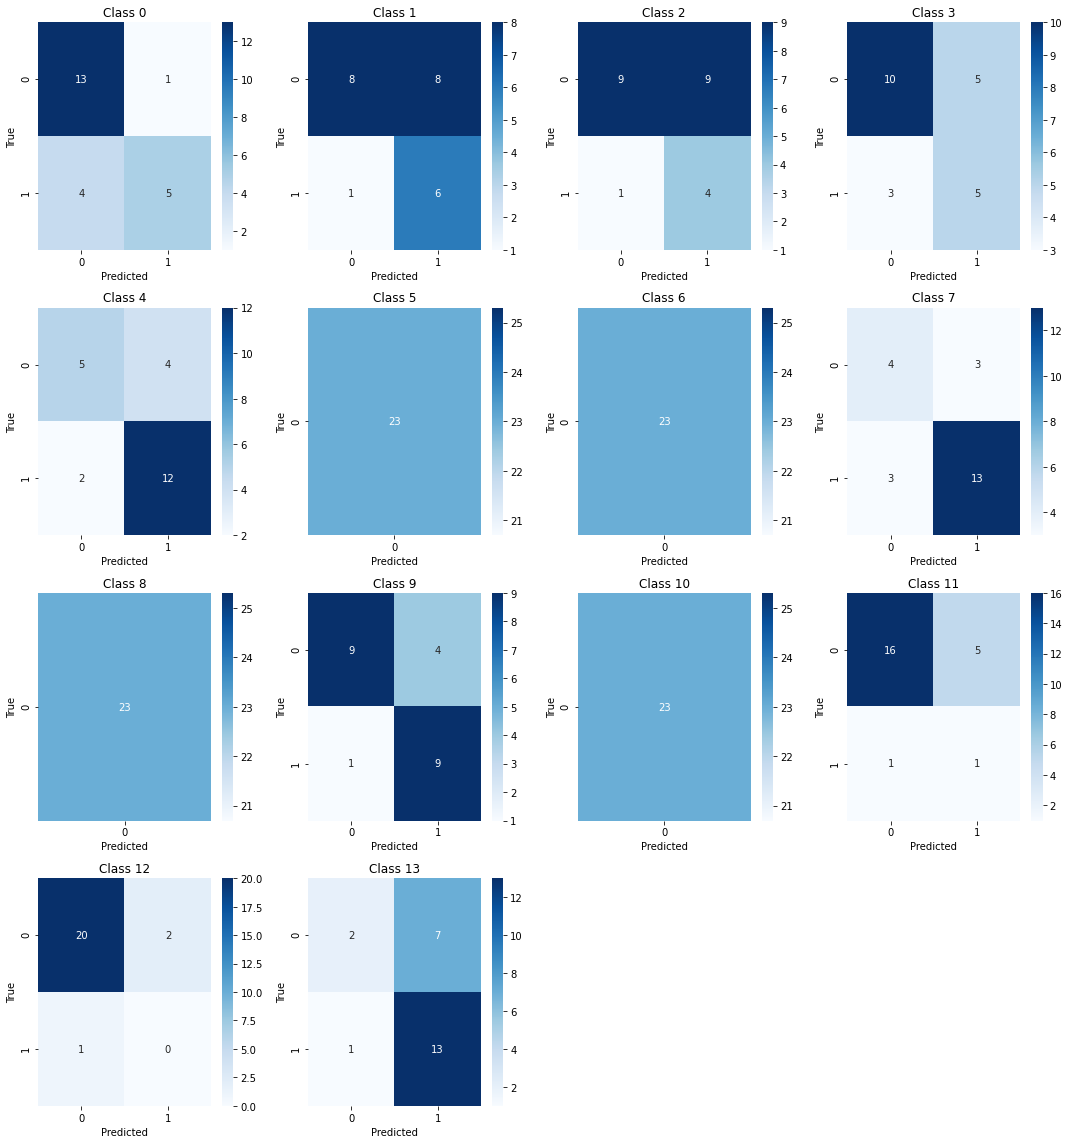

In [23]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import math

num_classes = all_labels.shape[1]

cols = 4
rows = math.ceil(num_classes / cols)

fig, axes = plt.subplots(rows, cols, figsize=(15, rows * 4))
axes = axes.flatten()

for i in range(num_classes):
    preds = (all_outputs[:, i] > best_thresholds[i]).astype(int)
    cm = confusion_matrix(all_labels[:, i], preds)

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i])
    axes[i].set_title(f"Class {i}")
    axes[i].set_xlabel("Predicted")
    axes[i].set_ylabel("True")

# fjern tomme plots
for j in range(num_classes, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

## Precision-Recall Curve

We use Precision-Recall curves to evaluate model performance on imbalanced data.

Precision measures how many predicted positives are correct, while recall measures how many actual positives are detected.

These curves provide a more realistic view of performance for rare classes in this multi-label classification task.

/Users/amnazafar/opt/anaconda3/lib/python3.8/site-packages/sklearn/metrics/_ranking.py:681: RuntimeWarning: invalid value encountered in divide
  recall = tps / tps[-1]
/Users/amnazafar/opt/anaconda3/lib/python3.8/site-packages/sklearn/metrics/_ranking.py:681: RuntimeWarning: invalid value encountered in divide
  recall = tps / tps[-1]
/Users/amnazafar/opt/anaconda3/lib/python3.8/site-packages/sklearn/metrics/_ranking.py:681: RuntimeWarning: invalid value encountered in divide
  recall = tps / tps[-1]
/Users/amnazafar/opt/anaconda3/lib/python3.8/site-packages/sklearn/metrics/_ranking.py:681: RuntimeWarning: invalid value encountered in divide
  recall = tps / tps[-1]


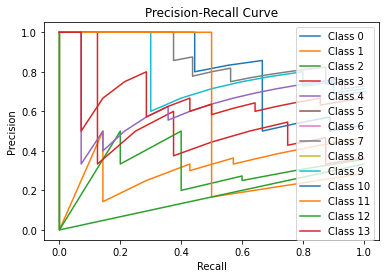

In [24]:
from sklearn.metrics import precision_recall_curve

for i in range(all_labels.shape[1]):
    precision, recall, _ = precision_recall_curve(all_labels[:, i], all_outputs[:, i])

    plt.plot(recall, precision, label=f"Class {i}")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.show()

## Visualization of Predictions

We visualize a subset of test images along with the model’s predicted labels.

This helps us qualitatively evaluate how well the model performs on unseen data.

Each image shows:
- Predicted labels (P)
- Ground truth labels (T)

In [25]:
def denormalize(img):
    mean = torch.tensor([0.485, 0.456, 0.406])
    std = torch.tensor([0.229, 0.224, 0.225])
    return img * std[:, None, None] + mean[:, None, None]

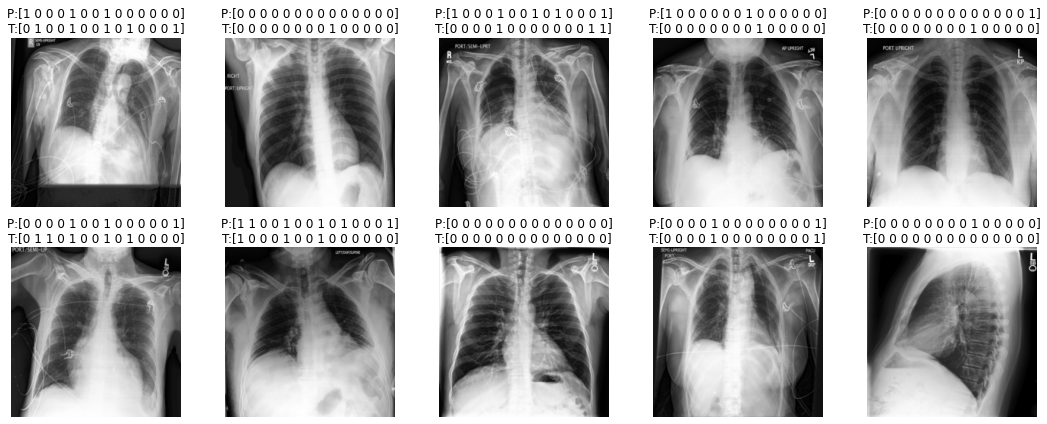

In [26]:
import matplotlib.pyplot as plt

model.eval()

images, labels = next(iter(test_loader))

with torch.no_grad():
    outputs = model(images)
    preds = torch.sigmoid(outputs)

fig, axes = plt.subplots(2, 5, figsize=(15, 6))

for i, ax in enumerate(axes.flatten()):
    img = denormalize(images[i]).permute(1,2,0).numpy()
    img = img.clip(0,1)

    ax.imshow(img)
    ax.axis("off")

    pred_labels = (preds[i] > 0.5).int().numpy()
    true_labels = labels[i].int().numpy()

    ax.set_title(f"P:{pred_labels}\nT:{true_labels}")

plt.tight_layout()
plt.show()

## Analysis

The training and validation losses show a gradual decrease, indicating that the model is learning over time.

The validation loss is slightly lower than the training loss, which may be due to regularization effects or data differences.

From the F1-scores and confusion matrices, the model performs better on frequent classes, while performance is lower on rare conditions.

The ROC curves further confirm that the model has reasonable discriminative ability across most classes.

Overall, the DenseNet121 model provides a solid baseline, but improvements such as class balancing, threshold tuning, and longer training could further enhance performance.

## Conclusion

In this project, we trained a DenseNet121 model for multi-label chest X-ray classification.

The model achieves reasonable performance on common diseases but struggles with rare classes due to class imbalance.

Evaluation using F1-scores, confusion matrices, and visual inspection shows that while the model captures general patterns, 
there is room for improvement.

Future work could include better handling of class imbalance, hyperparameter tuning, and longer training.

In [27]:
torch.save(model.state_dict(), "densenet_model.pth")